## O que é estatística?

Estatística é a área que nos ajuda a:
* Organizar dados
* Resumir dados
* Enxergar padrões
* Tomar decisões com mais critério

Em análise de dados, ela ajuda a responder:
* O que está acontecendo na empresa?
* Porque está acontecendo daquela forma?
* O que pode acontecer?
* Quais planos de ação irei tomar caso venha acontecer?
* Isso é comum ou estranho?
* Esse valor representa bem a base?

In [1]:
import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

In [3]:
base = {
  "idade": np.clip(np.random.normal(32, 6, 120).round(), 20, 55),
  "salario": np.clip(np.random.normal(4500, 1200, 120), 1800, 12000),
  "horas_estudo": np.clip(np.random.normal(6, 2, 120), 1, 15),
  "area": np.random.choice(
    ["Comercial", "Marketing", "Financeiro", "Operações", "RH"],
    size=120,
    p=[0.30, 0.20, 0.20, 0.20, 0.10]
  )
}

In [4]:
dataframe = pd.DataFrame(base)

In [5]:
dataframe

,idade,salario,horas_estudo,area
0,35.0,5449.238336,4.414959,Operações
1,31.0,3408.735054,5.770527,Financeiro
2,36.0,6183.353173,7.009975,RH
3,41.0,2817.778725,7.731510,Marketing
4,31.0,5204.228513,3.599407,Comercial
...,...,...,...,...
115,34.0,5260.702827,3.994941,RH
116,32.0,2069.828896,5.962974,Marketing
117,25.0,4723.745178,5.422683,Comercial
118,39.0,3705.856242,6.645437,Marketing


In [6]:
dataframe["performance"] = np.clip(55 + dataframe["horas_estudo"] * 4 + np.random.normal(0, 8, 120), 0, 100)

In [7]:
dataframe.head()

,idade,salario,horas_estudo,area,performance
0,35.0,5449.238336,4.414959,Operações,56.120297
1,31.0,3408.735054,5.770527,Financeiro,77.369148
2,36.0,6183.353173,7.009975,RH,72.604142
3,41.0,2817.778725,7.731510,Marketing,91.283422
4,31.0,5204.228513,3.599407,Comercial,72.330415


In [8]:
dataframe.shape

(120, 5)

In [9]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   idade         120 non-null    float64
 1   salario       120 non-null    float64
 2   horas_estudo  120 non-null    float64
 3   area          120 non-null    str    
 4   performance   120 non-null    float64
dtypes: float64(4), str(1)
memory usage: 4.8 KB


## Frequência
Frequência é a quantidade de vezes que um valor aparece.

Podemos olhar:
* Frequência absoluta -> contagem
* Frequência relativa -> proporção
* Percentual -> proporção em %

In [10]:
freq_area = dataframe["area"].value_counts().to_frame("frequencia")
freq_area["proporcao"] = dataframe["area"].value_counts(normalize=True)
freq_area["percentual"] = freq_area["proporcao"] * 100
freq_area

,frequencia,proporcao,percentual
area,,,
Financeiro,28,0.233333,23.333333
Comercial,27,0.225000,22.500000
Operações,22,0.183333,18.333333
RH,22,0.183333,18.333333
Marketing,21,0.175000,17.500000


In [11]:
import matplotlib.pyplot as plt

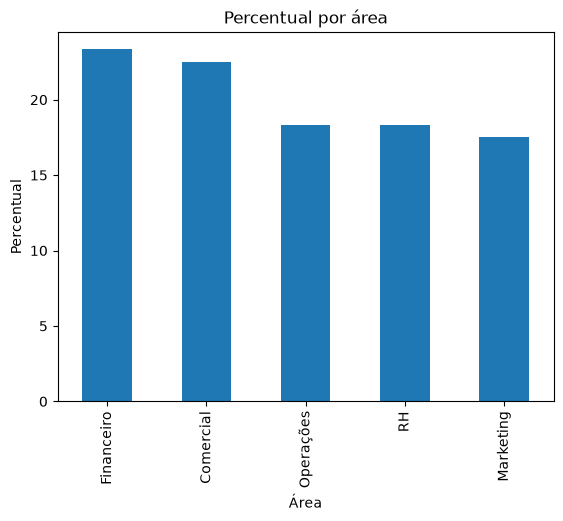

In [12]:
freq_area["percentual"].plot(kind="bar")
plt.title("Percentual por área")
plt.xlabel("Área")
plt.ylabel("Percentual")
plt.show()

## Média
A média é a soma dos valores dividida pela quantidade de valores

In [13]:
dataframe["salario"].mean()

np.float64(4589.237115184742)

## Mediana
A mediana é o valor central de um conjunto de dados ordenado
* Se a quantidade for ímpar -> pegamos o valor do meio
* Se for par -> fazemos a média dos dois valores centrais

In [14]:
dataframe["salario"].median()

np.float64(4722.652903981039)

## Moda
A moda é o valor que mais aparece

In [15]:
dataframe["area"].mode()

0    Financeiro
Name: area, dtype: str

In [16]:
salarios = pd.Series([3000, 3200, 3100, 2900, 3050, 3150, 3000, 2990, 3100, 100000])

print("Media: ", salarios.mean())
print("Mediana: ", salarios.median())

Media:  12749.0
Mediana:  3075.0


## Por que dispersão importa?
Porque duas bases podem ter a mesma média e comportamentos muito diferentes.

In [17]:
grupo1 = np.array([48, 50, 52, 49, 51])
grupo2 = np.array([30, 70, 40, 80, 30])

print("Media grupo1: ", grupo1.mean())
print("Media grupo2: ", grupo2.mean())

Media grupo1:  50.0
Media grupo2:  50.0


## Dispersão: Amplitude
É a diferença entre o maior e o menor valor de um determinado grupo de dados

In [18]:
amplitude = dataframe["salario"].max() - dataframe["salario"].min()
amplitude

np.float64(7053.448892774793)

## Dispersão: Variância e desvio padrão
* Variância mede o espelhamento em torno da média, ou seja, quanto os dados variam em relação a media
* Desvio padrão é a raiz da variância e costuma ser mais fácil de interpretar, pois significa quanto em média os dados se desviam, da média. 
  Se o número for baixo, os valores estão próximos, se for alto, esses valores são muito diferentes

In [19]:
print("Variancia: ", dataframe["salario"].var())
print("Desvio padrão: ", dataframe["salario"].std())

Variancia:  1475656.943702948
Desvio padrão:  1214.7662094835155


## Distribuição: Histograma
O histograma mostra como os dados estão distribuidos em faixas

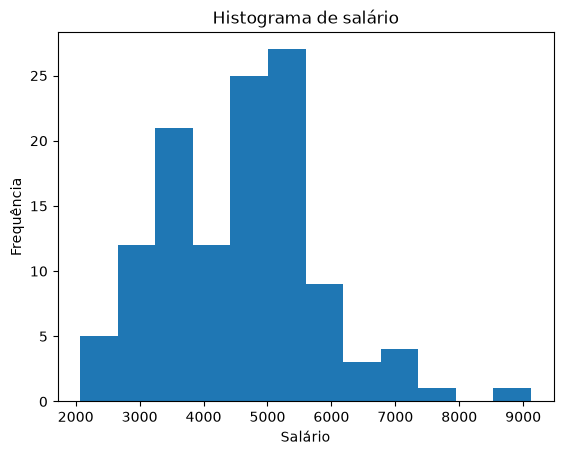

In [20]:
plt.hist(dataframe["salario"], bins=12)
plt.title("Histograma de salário")
plt.xlabel("Salário")
plt.ylabel("Frequência")
plt.show()

## Distribuição normal
É uma distribuição simétrica, concentrada no centro.

In [22]:
from scipy.stats import norm

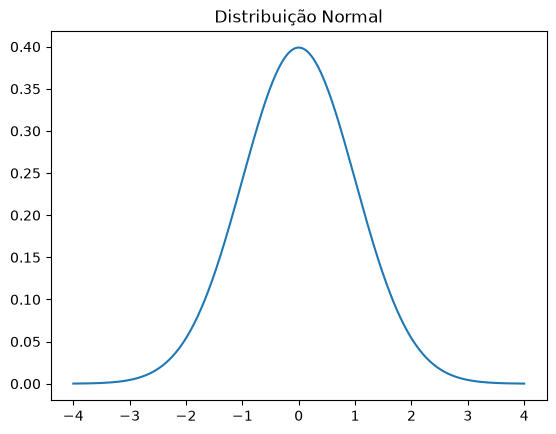

In [23]:
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

plt.plot(x, y)
plt.title("Distribuição Normal")
plt.show()

## Distribuição: Assimétrica
Nem toda distribuição é simétrica

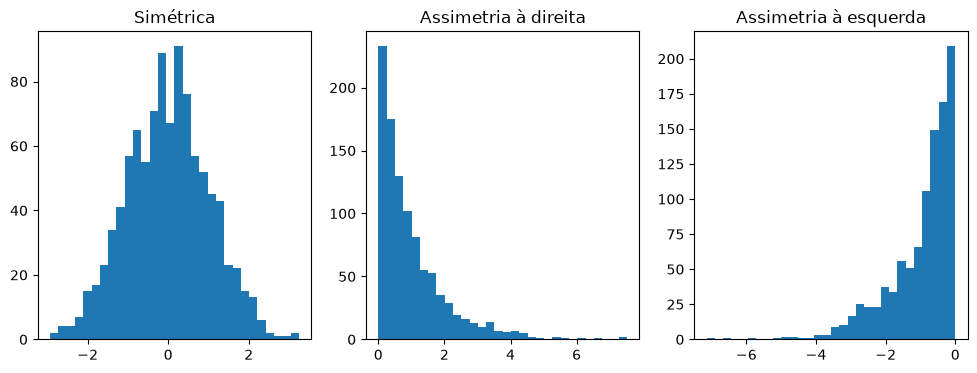

In [25]:
normal = np.random.normal(0, 1, 1000)
direita = np.random.exponential(1, 1000)
esquerda = -np.random.exponential(1, 1000)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(normal, bins=30)
plt.title("Simétrica")

plt.subplot(1, 3, 2)
plt.hist(direita, bins=30)
plt.title("Assimetria à direita")

plt.subplot(1, 3, 3)
plt.hist(esquerda, bins=30)
plt.title("Assimetria à esquerda")

plt.show()

## Quartis
Quartis dividem os dados em 4 partes:
* Q1 -> 25%
* Q2 -> 50% (mediana)
* Q3 -> 75%

In [26]:
print("Q1: ", dataframe["salario"].quantile(0.25))
print("Q2: ", dataframe["salario"].quantile(0.50))
print("Q3: ", dataframe["salario"].quantile(0.75))

Q1:  3589.789887716988
Q2:  4722.652903981039
Q3:  5294.77757245085


## Boxplot
O boxplot ajuda a resumir a distribuição e detectar outliers

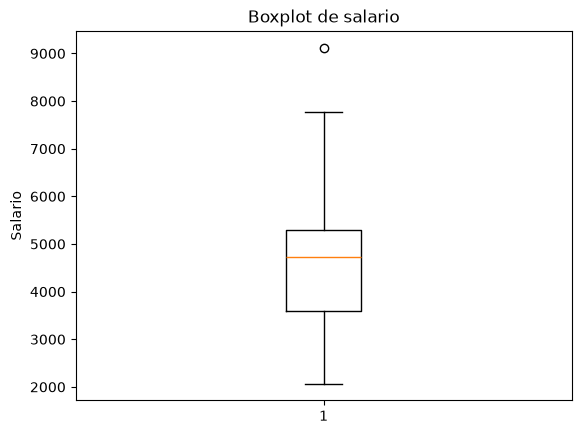

In [28]:
plt.boxplot(dataframe["salario"])
plt.title("Boxplot de salario")
plt.ylabel("Salario")
plt.show()

## Regra do InterQuartil - IQR
Outliers costumam ser buscados usando:
* Abaixo de Q1 - 1.5 * IQR
* Acima de Q3 + 1.5 * IQR

In [31]:
q1 = dataframe["salario"].quantile(0.25)
q3 = dataframe["salario"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = dataframe[(dataframe["salario"] < limite_inferior) | (dataframe["salario"] > limite_superior)]

print("Quantidade de outliers: ", len(outliers))
outliers.head()

Quantidade de outliers:  1


,idade,salario,horas_estudo,area,performance
89,35.0,9123.277789,7.256691,Operações,70.734604
